# Projeto de Predição de Risco de Crédito


# FASE 1 - Análise Exploratória de Dados (EDA)

Este notebook apresenta a primeira etapa do desenvolvimento do projeto de Machine Learning para predição de risco de crédito.

Nesta fase será realizada a Análise Exploratória dos Dados (EDA), com o objetivo de compreender a estrutura da base, identificar possíveis problemas de qualidade dos dados, analisar a distribuição das variáveis e levantar insights que orientarão as próximas etapas do pipeline de Machine Learning.

1.1 Importação das bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para realizar a análise exploratória dos dados. Essas ferramentas serão utilizadas para manipulação do conjunto de dados, cálculos estatísticos e construção das visualizações que apoiarão a interpretação dos resultados.


In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [130]:
# Configurações de visualização das colunas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

# Configuração dos gráficos
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carregamento da base de dados

Nesta etapa será realizado o carregamento do conjunto de dados utilizado no projeto. Após a leitura do arquivo CSV, será feita uma inspeção inicial para verificar se os dados foram importados corretamente e se a estrutura da base corresponde ao esperado.

In [131]:
df = pd.read_csv("../data/credit_risk_dataset.csv")

 1.3 Dicionário de Dados


| Coluna                       | Nome em Português                | Descrição                                                                                                                     |
| ---------------------------- | -------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| `person_age`                 | Idade do cliente                 | Idade do solicitante do empréstimo, em anos.                                                                                  |
| `person_income`              | Renda anual do cliente           | Renda anual declarada pelo cliente.                                                                                           |
| `person_home_ownership`      | Situação da moradia              | Condição da moradia do cliente (alugada, própria, financiada ou outros).                                                      |
| `person_emp_length`          | Tempo de emprego                 | Tempo de vínculo empregatício do cliente, em anos.                                                                            |
| `loan_intent`                | Finalidade do empréstimo         | Motivo pelo qual o cliente solicitou o empréstimo (educação, saúde, negócio, etc.).                                           |
| `loan_grade`                 | Classificação de risco           | Classificação de risco atribuída ao empréstimo (A a G), onde A representa menor risco e G maior risco.                        |
| `loan_amnt`                  | Valor do empréstimo              | Valor solicitado pelo cliente.                                                                                                |
| `loan_int_rate`              | Taxa de juros                    | Taxa de juros aplicada ao empréstimo (%).                                                                                     |
| `loan_status`                | Situação do empréstimo           | Variável alvo do projeto. **0 = adimplente** (pagou ou tende a pagar), **1 = inadimplente** (não pagou ou tende a não pagar). |
| `loan_percent_income`        | Percentual da renda comprometida | Percentual da renda anual comprometido pelo valor do empréstimo.                                                              |
| `cb_person_default_on_file`  | Histórico de inadimplência       | Indica se o cliente possui registro anterior de inadimplência (**Y = Sim**, **N = Não**).                                     |
| `cb_person_cred_hist_length` | Tempo de histórico de crédito    | Tempo de histórico de crédito do cliente, em anos.                                                                            |


1.4 Conhecendo o dataset

Nesta etapa será realizada uma inspeção inicial da base de dados com o objetivo de compreender sua estrutura, quantidade de registros, variáveis disponíveis e tipos de dados.

Essa análise inicial permite identificar características importantes do conjunto de dados e direcionar as próximas etapas de preparação e modelagem.


In [132]:
#vizualizr as primeiras linhas
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [133]:
#verificar o tamanho da base
df.shape

(32581, 12)

In [134]:
#verificar as colunas
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [135]:
#verificar os tipos de dados
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
                               ...   
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
Length: 12, dtype: object

In [136]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


1.5  Avaliação da Qualidade dos Dados


Nesta etapa será avaliada a qualidade dos dados, identificando valores ausentes e registros duplicados. Essas informações servirão de base para as decisões de tratamento na fase de preparação dos dados.

In [137]:
#verificar a quantidade de valores ausentes
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
                              ... 
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
Length: 12, dtype: int64

In [138]:
#verificar a quantidade de valores duplicados
df.duplicated().sum()

np.int64(165)

1.6 Análise descritiva



Nesta etapa serão analisadas as estatísticas descritivas das variáveis numéricas e categóricas da base de dados. O objetivo é compreender a distribuição dos dados, identificar possíveis valores extremos e obter informações que auxiliem nas etapas de preparação e modelagem.

In [139]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [140]:
df.describe(include="object")

C:\Users\Larissa\AppData\Local\Temp\ipykernel_9040\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


1.7  Análise Visual


Nesta etapa serão utilizadas visualizações gráficas para compreender a distribuição das variáveis numéricas, avaliar o balanceamento da variável alvo, analisar a correlação entre as variáveis e identificar possíveis outliers. Essas análises fornecerão evidências para as decisões de preparação dos dados e modelagem preditiva.

Histogramas:
 permitem visualizar a distribuição das variáveis numéricas do conjunto de dados, facilitando a identificação de padrões, assimetrias e possíveis valores extremos que poderão influenciar as etapas de preparação dos dados e modelagem.

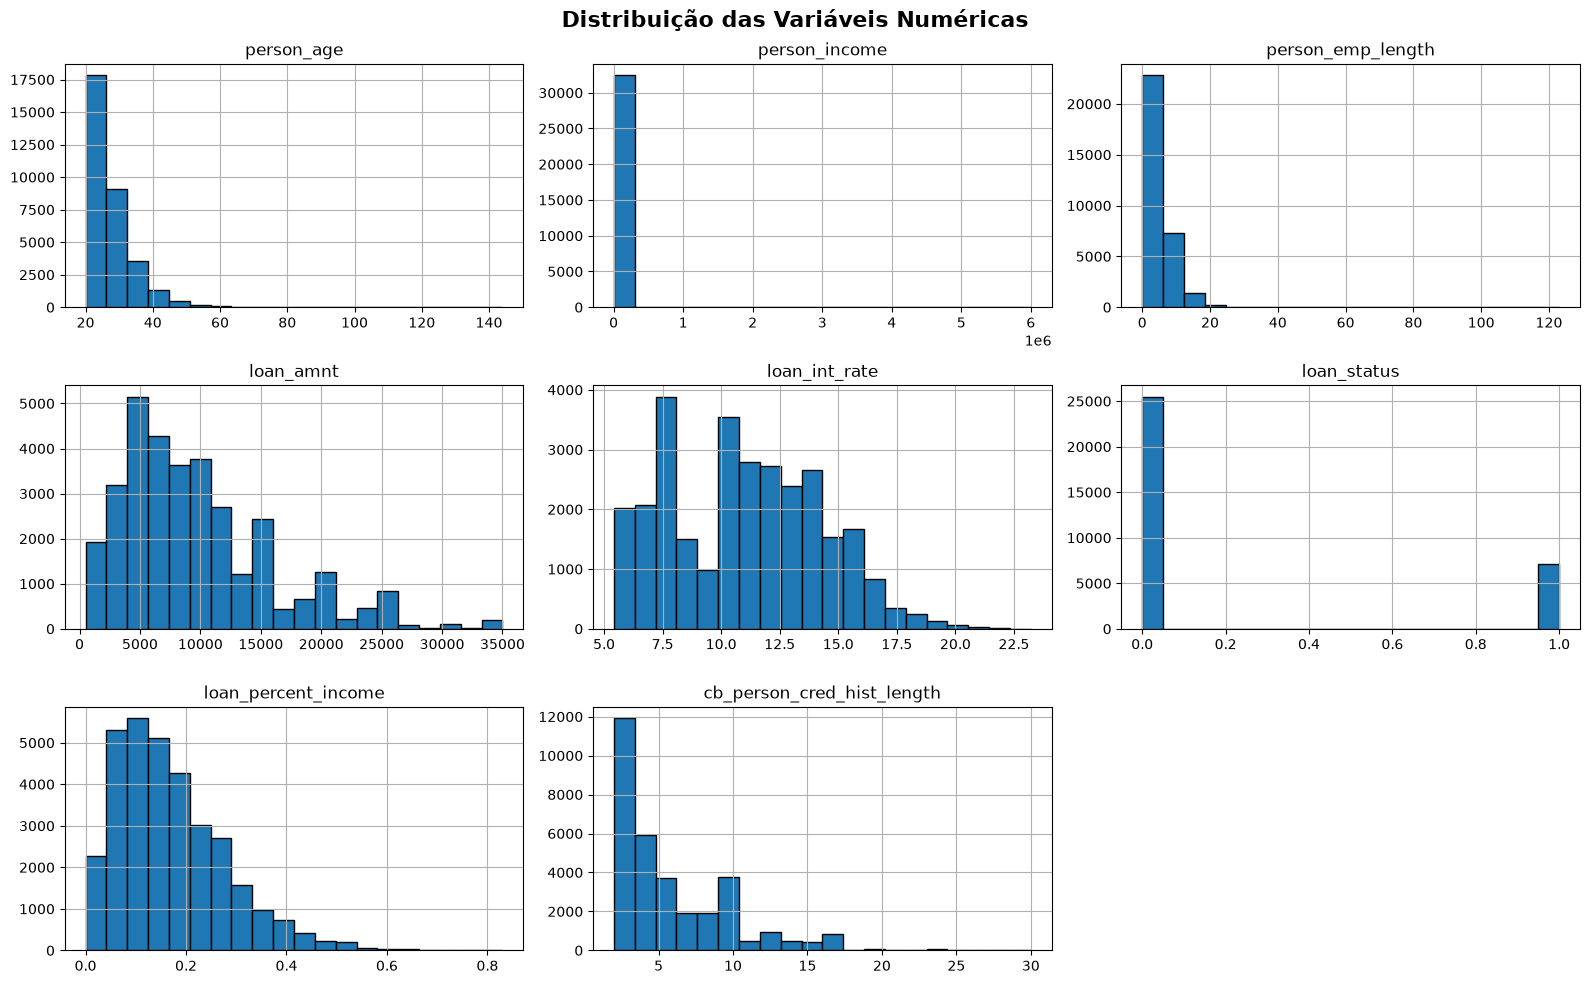

In [141]:

# Seleciona apenas as colunas numéricas
colunas_numericas = df.select_dtypes(include=["int64", "float64"]).columns

# Cria os histogramas
df[colunas_numericas].hist(
    figsize=(16, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Distribuição da Variável Alvo

A análise da variável alvo permite verificar se as classes estão balanceadas ou desbalanceadas. Essa informação é essencial para definir estratégias de preparação dos dados e evitar que o modelo favoreça a classe majoritária durante o treinamento.

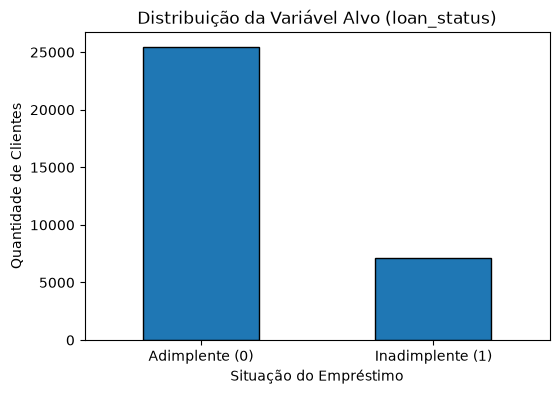

In [142]:
# Contagem das classes
contagem = df["loan_status"].value_counts().sort_index()

# Gráfico
plt.figure(figsize=(6,4))
contagem.plot(kind="bar", edgecolor="black")

plt.title("Distribuição da Variável Alvo (loan_status)")
plt.xlabel("Situação do Empréstimo")
plt.ylabel("Quantidade de Clientes")
plt.xticks([0,1], ["Adimplente (0)", "Inadimplente (1)"], rotation=0)

plt.show()

In [143]:
#PERCENTUAL
(df["loan_status"].value_counts(normalize=True) * 100).round(2)

loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64

A distribuição da variável alvo (loan_status) evidencia um desbalanceamento entre as classes. Aproximadamente 78,18% dos registros correspondem a clientes adimplentes (classe 0), enquanto apenas 21,82% representam clientes inadimplentes (classe 1). Esse cenário pode levar os modelos de Machine Learning a favorecerem a classe majoritária, reduzindo a capacidade de identificar corretamente clientes com maior risco de inadimplência. Para minimizar esse problema, será aplicada uma técnica de balanceamento de classes exclusivamente na base de treinamento, evitando vazamento de dados (data leakage) e proporcionando um treinamento mais equilibrado.

Correlação entre as Variáveis Numéricas

O mapa de calor (Heatmap) apresenta a correlação de Pearson entre as variáveis numéricas do conjunto de dados. Essa análise permite identificar relações lineares entre as variáveis e compreender quais atributos apresentam maior associação com a variável alvo (`loan_status`).

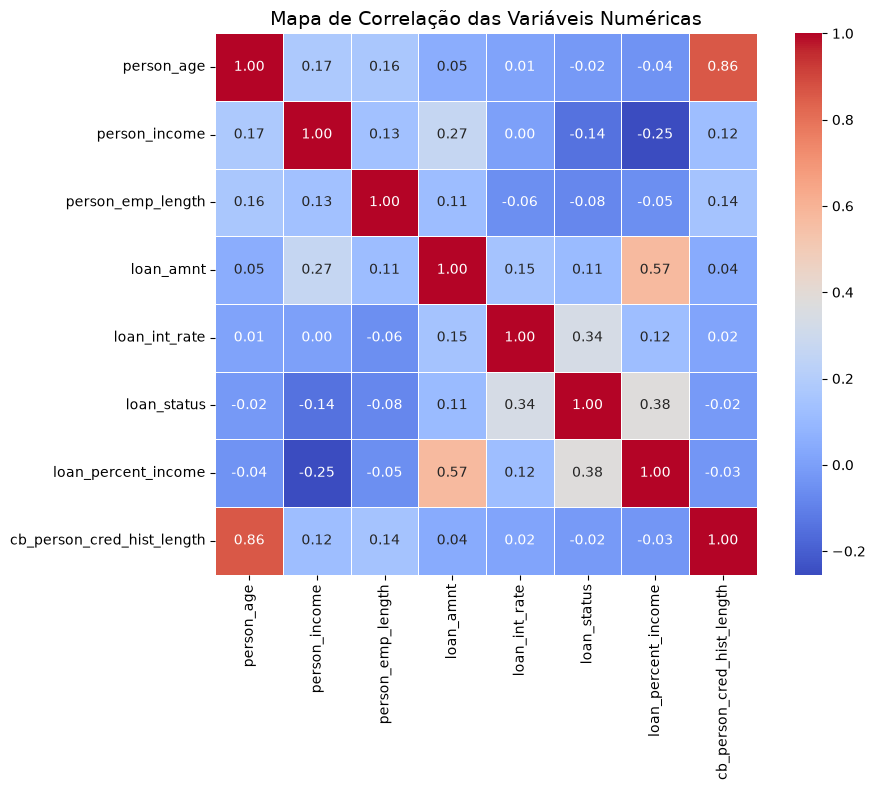

In [144]:
# Matriz de correlação das variáveis numéricas
correlacao = df.corr(numeric_only=True)

# Configuração da figura
plt.figure(figsize=(10, 8))

# Heatmap
sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

# Título
plt.title("Mapa de Correlação das Variáveis Numéricas", fontsize=14)

plt.tight_layout()
plt.show()

Identificação de Outliers

Os boxplots permitem identificar visualmente a presença de valores extremos (outliers) nas variáveis numéricas. Essa análise auxiliará na tomada de decisão sobre o tratamento desses valores na etapa de preparação dos dados, considerando o impacto que podem causar nos modelos de Machine Learning, especialmente no algoritmo KNN.

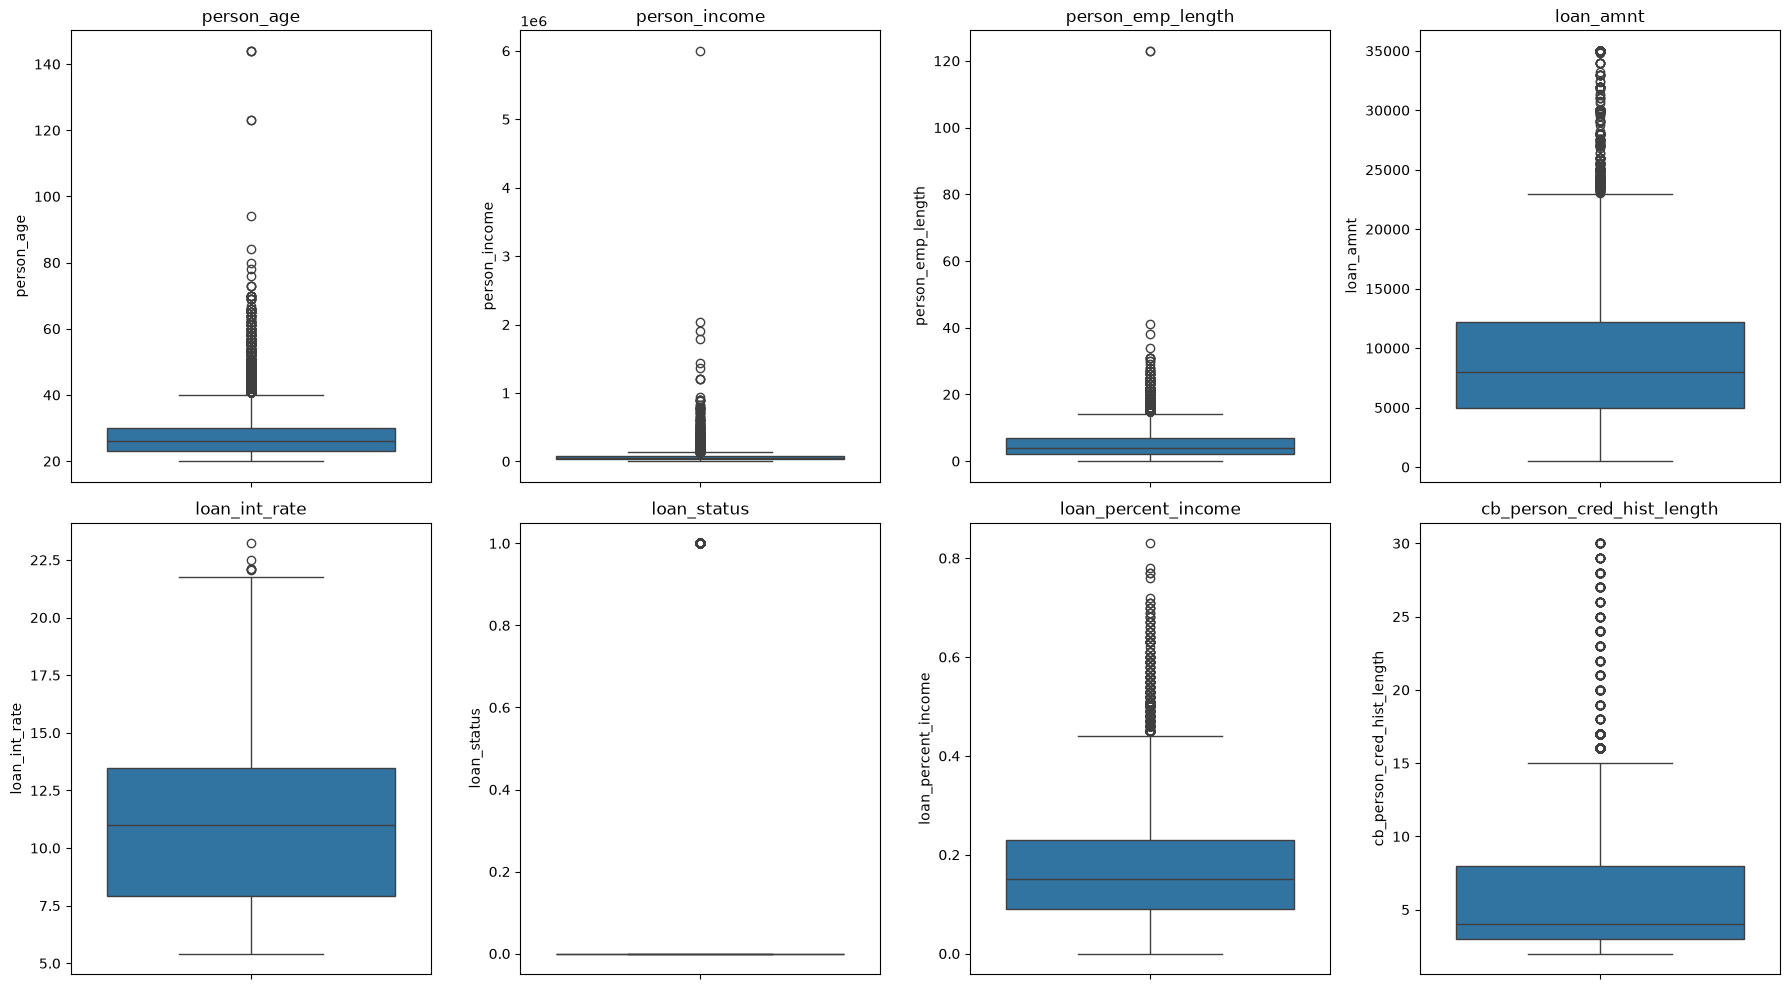

In [145]:
# Seleciona apenas as colunas numéricas
colunas_numericas = df.select_dtypes(include=["int64", "float64"]).columns

# Cria os boxplots
plt.figure(figsize=(18, 10))

for i, coluna in enumerate(colunas_numericas, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[coluna])
    plt.title(coluna)

plt.tight_layout()
plt.show()

 Identificação de Outliers -

A análise dos boxplots e das estatísticas descritivas revelou a presença de valores extremos em algumas variáveis. Foram identificadas inconsistências principalmente nas variáveis `person_age` e `person_emp_length`, com valores máximos incompatíveis com a realidade.

A variável `person_income` apresentou elevada dispersão, porém valores extremos podem representar clientes com renda elevada real, sendo necessário avaliar o impacto desses registros antes de removê-los.

Como os algoritmos utilizados possuem diferentes sensibilidades aos outliers, principalmente o KNN por utilizar cálculo de distância, o tratamento desses valores será realizado na etapa de preparação dos dados.

### Tomada de Decisão

A análise exploratória dos dados revelou características importantes sobre o conjunto de dados de risco de crédito. Foi identificado que a variável alvo (`loan_status`) apresenta desbalanceamento entre as classes, com aproximadamente 78,18% dos registros pertencentes à classe adimplente (0) e 21,82% à classe inadimplente (1). Esse comportamento deverá ser considerado durante a etapa de preparação dos dados, sendo avaliada a aplicação de técnicas de balanceamento exclusivamente na base de treinamento.

A análise de correlação indicou que a variável `loan_percent_income` (percentual da renda comprometida) apresentou a maior associação com a inadimplência, com correlação positiva de aproximadamente 0,38 com a variável alvo. Esse resultado sugere que o comprometimento da renda pode ser um fator relevante na avaliação de risco de crédito. Também foram observadas correlações negativas fracas entre `person_income` (renda do cliente) e `person_emp_length` (tempo de emprego) com a variável alvo, indicando que essas características possuem influência limitada quando analisadas isoladamente.

Durante a análise dos valores ausentes, foram identificadas informações faltantes nas variáveis `person_emp_length` e `loan_int_rate`, sendo necessário realizar tratamento adequado para evitar perda de informações relevantes. A análise dos boxplots revelou possíveis inconsistências em variáveis como `person_age` e `person_emp_length`, com valores extremos incompatíveis com a realidade, que deverão ser investigados e tratados antes da modelagem.

Com base nessas observações, a etapa de preparação dos dados será direcionada para o tratamento de valores ausentes, remoção ou correção de registros inconsistentes, transformação das variáveis categóricas e normalização dos dados. Essas etapas são especialmente importantes devido à utilização do algoritmo KNN, que é sensível à escala das variáveis e à presença de outliers.

# Fase 2: Tratamento e Limpeza (Data Prep)

Garantir que os dados estejam consistentes e adequados para a etapa de modelagem, tratando valores ausentes, duplicados, inconsistências e possíveis problemas de qualidade.



2.1 Cópia da Base Original

Para preservar a integridade dos dados originais, será criada uma cópia do dataset antes da realização das etapas de limpeza e transformação.

In [146]:
df_clean = df.copy()

2.2 Contagem dos Nulos


In [147]:
df_clean.isnull().sum()


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
                              ... 
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
Length: 12, dtype: int64

In [148]:
#porcentagem sobre o dataset
# Quantidade de valores ausentes
nulos = df_clean.isnull().sum()

# Percentual de valores ausentes
percentual_nulos = (df_clean.isnull().mean() * 100).round(2)

# Tabela resumo

resumo_nulos = pd.DataFrame({
    "Quantidade": nulos,
    "Percentual (%)": percentual_nulos
})

# Exibir apenas colunas com valores ausentes
resumo_nulos[resumo_nulos["Quantidade"] > 0]

,Quantidade,Percentual (%)
person_emp_length,895,2.75
loan_int_rate,3116,9.56


In [149]:
#- Decisão sobre a estratégia de tratamento
df_clean[["person_emp_length", "loan_int_rate"]].median()

person_emp_length     4.00
loan_int_rate        10.99
dtype: float64

In [150]:
df_clean[["person_emp_length", "loan_int_rate"]].mean()

person_emp_length     4.789686
loan_int_rate        11.011695
dtype: float64

2.3 Tratamento dos Valores Ausentes

Após a análise dos valores ausentes e das estatísticas descritivas, optou-se por realizar a imputação utilizando a mediana. Essa estratégia foi escolhida por ser menos sensível à presença de valores extremos, especialmente na variável `person_emp_length`, que apresentou outliers durante a análise exploratória.

Na variável `loan_int_rate`, a média e a mediana apresentaram valores muito próximos, indicando baixa influência de valores extremos. Ainda assim, foi mantida a mediana para padronizar a estratégia de imputação e garantir maior robustez ao tratamento dos dados.

In [151]:
df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(
    df_clean["person_emp_length"].median()
)

df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(
    df_clean["loan_int_rate"].median()
)

In [152]:
#chegagem se existem vários nulos
df_clean.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
                             ..
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
Length: 12, dtype: int64

2.4 Tratamento de Registros Duplicados

A presença de registros duplicados pode introduzir vieses na análise e no treinamento dos modelos de Machine Learning, uma vez que determinadas observações passam a ter maior peso na aprendizagem. Nesta etapa, foi realizada a verificação da existência de registros duplicados e, quando identificados, sua remoção da base de dados.

In [153]:
# Quantidade de registros duplicados
duplicatas = df_clean.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicatas}")

Quantidade de registros duplicados: 165


In [154]:
# Remoção dos registros duplicados
df_clean = df_clean.drop_duplicates()

# Verificação
print(f"Quantidade de registros duplicados: {df_clean.duplicated().sum()}")

Quantidade de registros duplicados: 0


In [155]:
# verificar o tamanho da base
print(df_clean.shape)

(32416, 12)


Após a verificação da qualidade dos dados, foram identificados 165 registros duplicados. Como essas observações não adicionavam novas informações ao conjunto de dados, optou-se por removê-las, evitando que determinados perfis de clientes tivessem influência desproporcional durante o treinamento dos modelos de Machine Learning. Após a remoção, a base passou a conter 32.416 registros únicos.

2.5 Tratamento de Valores Inconsistentes e Outliers

In [156]:
df_clean[df_clean["person_age"] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,10.99,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


Durante a análise foram identificados cinco registros com idades de 123 e 144 anos, valores incompatíveis com a realidade e considerados inconsistências de cadastro. Como esses registros representam uma parcela muito pequena da base de dados, optou-se por removê-los, evitando que influenciassem negativamente o treinamento dos modelos de Machine Learning.

Esses registros representam apenas 5 de mais de 32 mil observações, ou seja, menos de 0,02% da base.

In [157]:
# Remoção de registros com idade inconsistente
df_clean = df_clean[df_clean["person_age"] <= 100]

# Verificação
print(df_clean["person_age"].max())
print(df_clean.shape)

94
(32411, 12)


In [158]:
df_clean[df_clean["person_emp_length"] > 60]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


É impossível uma pessoa de 21 ou 22 anos ter 123 anos de experiência profissional.

In [159]:
# Remove registros com tempo de emprego inconsistente
df_clean = df_clean[df_clean["person_emp_length"] <= 60]
print(df_clean["person_emp_length"].max())

41.0


Foram identificados dois registros com tempo de emprego igual a 123 anos. Como esses valores são incompatíveis com a idade dos respectivos clientes e não havia informações que permitissem sua correção de forma confiável, optou-se pela remoção desses registros para preservar a consistência do conjunto de dados.

In [160]:
#verificar valores ausentes
print(df_clean.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
                             ..
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
Length: 12, dtype: int64


In [161]:
#verificar duplicatas
print(df_clean.duplicated().sum())

0


Ao final da etapa de limpeza, verificou-se que a base de dados não possui mais valores ausentes nem registros duplicados. As inconsistências identificadas durante a análise exploratória, como idades e tempos de emprego incompatíveis com a realidade, foram removidas. Dessa forma, o conjunto de dados encontra-se consistente e preparado para as etapas de transformação das variáveis e construção dos modelos de Machine Learning.

# 3. Feature Engineering (Engenharia de Atributos)

A etapa de Feature Engineering tem como objetivo preparar e aprimorar o conjunto de dados para o treinamento dos modelos de Machine Learning. Nessa fase, são criadas novas variáveis a partir das informações existentes, avaliadas possíveis redundâncias entre atributos e aplicadas transformações necessárias para que os algoritmos consigam aprender padrões de forma mais eficiente.

3.1 Criação da feature comprometimento_renda

In [162]:
# Criação da nova variável comprometimento_renda
df_clean["comprometimento_renda"] = (
    (df_clean["loan_amnt"] / df_clean["person_income"]) * 100).round(2)

# Visualização
df_clean[["loan_amnt",
          "person_income",
          "comprometimento_renda"]].head()

,loan_amnt,person_income,comprometimento_renda
1,1000,9600,10.42
2,5500,9600,57.29
3,35000,65500,53.44
4,35000,54400,64.34
5,2500,9900,25.25


# Fase 4 – Separação, Balanceamento e Escalonamento Seguro

4.1 Encoding
Converter as variáveis categóricas (texto) em valores numéricos 

In [163]:
for coluna in [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]:
    print(f"\n{coluna}")
    print(df_clean[coluna].value_counts())


person_home_ownership
person_home_ownership
RENT        16374
MORTGAGE    13366
OWN          2563
OTHER         106
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6409
MEDICAL              6042
VENTURE              5679
PERSONAL             5496
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

loan_grade
loan_grade
A    10702
B    10384
C     6436
D     3619
E      963
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26680
Y     5729
Name: count, dtype: int64


Tipo 1 — Binária - Mapeamento binário

In [164]:
#conversão para 0 e 1
df_clean["cb_person_default_on_file"] = (
    df_clean["cb_person_default_on_file"]
    .str.strip() #Remove espaços no começo e no final do texto.
    .str.upper() #padronização para maiúsculo
    .map({"N":0, "Y":1}))

In [ ]:
#conferir valores
df_clean["cb_person_default_on_file"].value_counts()

cb_person_default_on_file
0    26680
1     5729
Name: count, dtype: int64

In [166]:
df_clean["cb_person_default_on_file"].dtype

dtype('int64')

A variável `cb_person_default_on_file` possui apenas duas categorias
(N e Y), representando se o cliente possui histórico de inadimplência
registrado. Por ser uma variável binária, foi realizada a conversão
direta para valores numéricos, onde N foi representado por 0 e Y por 1.

Antes da conversão, a variável estava no formato textual. Após o
processamento, passou a ser representada como uma variável inteira,
permitindo sua utilização pelos algoritmos de Machine Learning.

In [167]:
# Verifica se o processo de encoding gerou valores ausentes
df_clean["cb_person_default_on_file"].isnull().sum()

np.int64(0)

Tipo 2- Ordinal (com ordem) - Codificação ordinal

In [169]:
# Criando um dicionário para transformar a classificação
# de crédito em valores numéricos mantendo a ordem de risco

grade_map = {
    "A": 0,  # Menor risco
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4,
    "F": 5,
    "G": 6   # Maior risco
}


# Aplicando o mapeamento na coluna loan_grade
# Cada categoria textual será substituída pelo valor correspondente

df_clean["loan_grade"] = (
    df_clean["loan_grade"]
    .map(grade_map))

In [171]:
# Conferir se as categorias foram transformadas corretamente

df_clean["loan_grade"].unique()

array([1, 2, 0, 3, 4, 5, 6])

In [172]:
# Contar registros por nível de risco
# sort_index organiza do menor para o maior risco

df_clean["loan_grade"].value_counts().sort_index()

loan_grade
0    10702
1    10384
2     6436
3     3619
4      963
5      241
6       64
Name: count, dtype: int64

Nós não usamos Label Encoding automático porque ele pode criar uma ordem falsa nas variáveis que não possuem ordem real. 
manualmente podemos deixa explícita a regra

Tipo 3 - categórica nominal - One-Hot

In [173]:
# Verificando as categorias existentes antes do One-Hot Encoding

df_clean["person_home_ownership"].unique()

<StringArray>
['OWN', 'MORTGAGE', 'RENT', 'OTHER']
Length: 4, dtype: str

In [174]:
# Aplicando One-Hot Encoding na variável person_home_ownership
# drop_first=True remove a primeira categoria criada para evitar redundância

df_clean = pd.get_dummies(
    df_clean,
    columns=["person_home_ownership"],
    drop_first=True
)

In [175]:
# Visualizando as novas colunas criadas

df_clean.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_intent',
       'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'comprometimento_renda',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT'],
      dtype='str')

In [180]:
# Visualizando algumas linhas para verificar o resultado

# Visualizando algumas linhas para verificar o resultado

df_clean[
    [
        "person_home_ownership_RENT",
        "person_home_ownership_OTHER",
        "person_home_ownership_OWN"
    ]
].head()

,person_home_ownership_RENT,person_home_ownership_OTHER,person_home_ownership_OWN
1,False,False,True
2,False,False,False
3,True,False,False
4,True,False,False
5,False,False,True


In [181]:
# Verificando o tipo das novas variáveis criadas pelo One-Hot Encoding

df_clean[
    [
        "person_home_ownership_RENT",
        "person_home_ownership_OTHER",
        "person_home_ownership_OWN"
    ]
].dtypes

person_home_ownership_RENT     bool
person_home_ownership_OTHER    bool
person_home_ownership_OWN      bool
dtype: object

In [182]:
# Selecionando as colunas criadas pelo One-Hot Encoding
# e convertendo valores booleanos (True/False)
# para valores inteiros (1/0)

cols_home = [
    "person_home_ownership_RENT",
    "person_home_ownership_OTHER",
    "person_home_ownership_OWN"
]


# Aplicando a conversão para inteiro
df_clean[cols_home] = (
    df_clean[cols_home]
    .astype(int)
)

In [183]:
# Conferindo os novos tipos das colunas

df_clean[cols_home].dtypes

person_home_ownership_RENT     int64
person_home_ownership_OTHER    int64
person_home_ownership_OWN      int64
dtype: object

In [184]:
df_clean[cols_home].head()

,person_home_ownership_RENT,person_home_ownership_OTHER,person_home_ownership_OWN
1,0,0,1
2,0,0,0
3,1,0,0
4,1,0,0
5,0,0,1


 One-Hot Encoding da variável person_home_ownership

A variável `person_home_ownership` representa categorias nominais de
moradia, sem uma relação de ordem entre seus valores. Dessa forma, foi
aplicado One-Hot Encoding para transformar as categorias textuais em
variáveis binárias.

Foi utilizado `drop_first=True` para remover uma das categorias e evitar
redundância entre variáveis dummy. As variáveis resultantes foram
convertidas para o formato inteiro (0 e 1), adequado para os algoritmos
de Machine Learning.

In [185]:
# Verificando as categorias existentes antes do One-Hot Encoding

df_clean["loan_intent"].unique()

<StringArray>
[        'EDUCATION',           'MEDICAL',           'VENTURE',
          'PERSONAL',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

In [186]:
# Aplicando One-Hot Encoding na variável loan_intent
# Como a variável é nominal, não existe uma ordem entre as categorias.
# O parâmetro drop_first=True evita criar uma coluna redundante.

df_clean = pd.get_dummies(
    df_clean,
    columns=["loan_intent"],
    drop_first=True
)

In [187]:
# Listando as colunas relacionadas ao motivo do empréstimo

[col for col in df_clean.columns if "loan_intent" in col]

['loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE']

In [188]:
# Verificando o tipo das novas variáveis criadas

df_clean[
    [col for col in df_clean.columns if "loan_intent" in col]
].dtypes

loan_intent_EDUCATION          bool
loan_intent_HOMEIMPROVEMENT    bool
loan_intent_MEDICAL            bool
loan_intent_PERSONAL           bool
loan_intent_VENTURE            bool
dtype: object

In [189]:
# Convertendo variáveis booleanas para inteiros (0 e 1)

loan_cols = [
    col for col in df_clean.columns
    if "loan_intent" in col
]

df_clean[loan_cols] = df_clean[loan_cols].astype(int)

4.2 Separação x e y + Train/Test Split

In [191]:
#Separando a variável alvo(target)
#essa é a informação que o modelo deverá prever 

y = df_clean["loan_status"]


#separando as variáveis preditoras(features)
# removemos loan-status porque ela não pode ser usa na entrada,
#caso contrário o modelo teria acesso á resposta

x = df_clean.drop(columns=["loan_status"])

In [193]:
# Conferindo o tamanho das variáveis

print("x:", x.shape)
print("y:", y.shape)

x: (32409, 18)
y: (32409,)


Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

#separando os dados em treino e teste 

# test_size=0.20:
# reserva 20% dos dados para teste
#
# stratify=y:
# mantém a mesma proporção da variável alvo nos dois grupos, faz a classes terem a mesma proporção 
#
# random_state:
# garante que a divisão seja reproduzível


x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [196]:
# Conferindo a proporção da variável alvo no treino e teste

print(y_train.value_counts(normalize=True))
print()
print(y_test.value_counts(normalize=True))

loan_status
0    0.781309
1    0.218691
Name: proportion, dtype: float64

loan_status
0    0.78124
1    0.21876
Name: proportion, dtype: float64


 Separação em treino e teste

Os dados foram divididos em conjuntos de treino (80%) e teste (20%) utilizando `train_test_split`.

Foi utilizado o parâmetro `stratify=y` para preservar a proporção das classes da variável alvo (`loan_status`) em ambos os conjuntos. Como a base é desbalanceada, essa estratégia evita que uma das classes fique sub ou super-representada após a divisão, tornando a avaliação do modelo mais confiável.

Optou-se pelo SMOTE para o balanceamento das classes, pois essa técnica gera exemplos sintéticos da classe minoritária, preservando todos os registros da classe majoritária. Como a base possui um desbalanceamento moderado e um número de observações que permite esse procedimento, o SMOTE tende a aproveitar melhor as informações disponíveis do que técnicas de subamostragem, como o Random Under Sampling.

In [202]:
# Importando a técnica SMOTE para balanceamento das classes

from imblearn.over_sampling import SMOTE

# imblearn = biblioteca Imbalanced-learn, especializada em bases desbalanceadas.
# over_sampling = técnicas que aumentam a classe minoritária.
# SMOTE = algoritmo que cria exemplos sintéticos da classe minoritária.

In [204]:
# Criando o objeto SMOTE
smote = SMOTE(random_state=42)

In [205]:
# Aplicando o SMOTE somente no conjunto de treino
# O conjunto de teste permanece inalterado para evitar Data Leakage

x_train_bal, y_train_bal = smote.fit_resample(
    x_train,
    y_train)

# fit: analisa a distribuição das classes e identifica qual é a minoritária.
# resample: cria novas amostras sintéticas dessa classe até equilibrar o conjunto.
#X_train_bal → variáveis preditoras balanceadas.
# y_train_bal → variável alvo balanceada.


In [208]:
print(y_train.value_counts())
print()
print(y_train_bal.value_counts())

loan_status
0    20257
1     5670
Name: count, dtype: int64

loan_status
0    20257
1    20257
Name: count, dtype: int64



A variável alvo apresentava desbalanceamento, com predominância da classe `0` (clientes adimplentes) em relação à classe `1` (clientes inadimplentes).

Para reduzir esse desbalanceamento, foi aplicada a técnica **SMOTE (Synthetic Minority Over-sampling Technique)** exclusivamente no conjunto de treino. Essa técnica gera exemplos sintéticos da classe minoritária até igualar a quantidade de registros entre as classes.

O balanceamento foi realizado somente após a divisão entre treino e teste, evitando Data Leakage e garantindo que o conjunto de teste permanecesse representativo de dados nunca vistos pelo modelo.